# Training — P1 baselines + Pipeline A on the local logs

Multi-frame training over the converted py123d logs (split **by log**: last one held out for validation — frames within a log are correlated, a per-frame split would leak). All implementation lives in the `.py` modules; this notebook only wires them:

| block | module |
|---|---|
| targets + loss + loop | `train.py` (`TargetEncoder`, `CenterPointLoss`, `train_model`) |
| models | `network.py` (`LidarOnlyDetector`, `PipelineA/B/C`) |
| stereo input cache | `data.py` (`precompute_stereo_inputs`) |
| decode + distance-AP | `evaluation.py` (`CenterPointDecoder`, `evaluate_model`) |

In [1]:
# Repo-root bootstrap — lets this notebook run from notebooks/ or the repo root.
import os, sys
from pathlib import Path
_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "globals.py").exists())
os.chdir(_ROOT)
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
print("repo root:", _ROOT)

repo root: /home/leonardo/Desktop/AIRO/stereo-lidar-perception


## 1. Imports

In [ ]:
import os
from pathlib import Path
import data  # noqa: F401  (repo module; also used below)

# Point py123d at the repo-local roots (now symlinks -> the external Volume where
# the dataset lives). setdefault respects the env vars if already exported.
_REPO = Path(data.__file__).resolve().parent
os.environ.setdefault("PY123D_DATA_ROOT", str(_REPO / "data"))
os.environ.setdefault("KITTI360_DATA_ROOT", str(_REPO / "KITTI-360"))

import matplotlib.pyplot as plt
import torch

import data
import globals as G
import utils
from data import (Py123dDataset, StereoSGBMConfig,
                  precompute_stereo_inputs, stereo_cache_root)
import igev_matcher  # registers the IGEV learned matcher (lazy)
from evaluation import (CenterPointDecoder, compare_reports, evaluate_late_fusion,
                        evaluate_model, load_report, print_ap_report,
                        save_history, save_report)
from network import (CameraOnlyDetector, LidarOnlyDetector, PipelineA,
                     PipelineB, PipelineC, StereoBEVConfig, lidar_points)
from train import TargetEncoder, set_seed, train_model, validate

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

/home/leonardo/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


device: cuda


## 2. Globals

In [3]:
print("grid:", G.GRID_SIZE, "| x:", G.X_RANGE, "| y:", G.Y_RANGE)
print("classes:", G.CLASSES)

# --- run configuration -------------------------------------------------
# MODEL: "lidar" | "camera" (single-sensor baselines)
#        "pipeline_a" (concat-conv fusion) | "pipeline_b" (+ painted lidar)
#        "pipeline_c" (cross-attention fusion)
MODEL = "camera"
EPOCHS = 4
LR = 1e-3
ACCUM = 4  # frames per optimizer step (batch-1 + accumulation)
SEED = 0   # python/numpy/torch/CUDA RNGs (weight init, shuffling)

# Split is now by DRIVE via the converted py123d splits (no in-notebook split):
#   train = kitti360_train  -> drives 0003 + 0007 + 0009
#   val   = kitti360_val    -> drive 0010 (held-out, rich in every class)

# camera stem (camera / pipeline_* only): "efficientnet" trains a ~1M-param CNN
# from scratch (weak); "yolo26" uses a COCO-pretrained backbone. FREEZE keeps it
# fixed so only the head/BEV/context train — the strong first baseline to try.
CAMERA_BACKBONE = "yolo26"  # "efficientnet" | "yolo26"
FREEZE_BACKBONE = True

# camera-branch DEPTH source: "igev" = dense learned stereo (recommended) via the
# stereo_inputs_igev cache; "sgbm" = classic sparse block matching. Training only
# READS the cache (no matcher at runtime).
MATCHER = "igev"  # "igev" | "sgbm"

tag = "" if MODEL == "lidar" else f"_{CAMERA_BACKBONE}_{MATCHER}"
CKPT = f"checkpoints/{MODEL}{tag}.pt"   # best-val weights (train_model writes it)
RESULTS = f"results/{MODEL}{tag}.json"   # AP report (§7 writes; §9 compares)
HISTORY = f"results/{MODEL}{tag}_history.json"   # loss curves (§6 writes)

set_seed(SEED)  # reproducible runs (not bit-deterministic: CUDA atomics)

grid: (200, 160) | x: (0.0, 50.0) | y: (-20.0, 20.0)
classes: ('VEHICLE', 'PERSON', 'TWO_WHEELER', 'TRAFFIC_SIGN', 'TRAIN')


## 3. Data — train/val by drive

`train = kitti360_train` (drives **0003 + 0007 + 0009**) · `val = kitti360_val` (drive **0010**, held out). Splitting by whole drive is the only leak-free split (consecutive frames of one drive are strongly correlated). Drive 0009 was added specifically because 0003/0007 are the dataset's two *poorest* drives for PERSON/TWO_WHEELER; 0010 is rich in every class and makes a proper validation set.

In [4]:
# Split by DRIVE: train = kitti360_train (0003+0007+0009), val = kitti360_val (0010).
# Frames within a drive are correlated, so holding out a whole drive is the only
# leak-free split — and 0010 now carries every class (VEHICLE/PERSON/TWO_WHEELER/
# TRAFFIC_SIGN/GENERIC_OBJECT, + the rare TRAIN/TRAFFIC_LIGHT).
train_ds = Py123dDataset(split_names=["kitti360_train"])
val_ds = Py123dDataset(split_names=["kitti360_val"])
train_frames = list(train_ds)
val_frames = list(val_ds)
print(train_ds)
print(val_ds)
print(f"train: {len(train_frames)} frames / {train_ds.scene_count} drives | "
      f"val: {len(val_frames)} frames / {val_ds.scene_count} drives")

DEBUG: PY123D_DATA_ROOT resolved to /media/leonardo/Volume/stereo-lidar-data/data
DEBUG: found 3 scenes using filter SceneFilter(datasets=None, split_types=None, split_names=['kitti360_train'], log_names=None, has_map=None, map_has_z=None, map_locations=None, map_version=None, log_locations=None, log_version=None, scene_uuids=None, target_iteration_duration_s=None, future_duration_s=None, history_duration_s=None, timestamp_threshold_s=None, target_iteration_stride=None, future_num_iterations=None, history_num_iterations=None, iteration_threshold=None, required_scene_modalities=None, custom_filter_fns=None, num_chunks=None, chunk_idx=None, max_num_scenes=None, shuffle=False)
DEBUG: PY123D_DATA_ROOT resolved to /media/leonardo/Volume/stereo-lidar-data/data
DEBUG: found 1 scenes using filter SceneFilter(datasets=None, split_types=None, split_names=['kitti360_val'], log_names=None, has_map=None, map_has_z=None, map_locations=None, map_version=None, log_locations=None, log_version=None, sce

## 4. Stereo input cache (one-time, camera training only)

SGBM is ~1–2 s/frame on CPU and never changes, so precompute the camera-branch inputs once (<1 MB/frame, resumable — already-cached frames are skipped). Not needed for the LiDAR-only baseline; expect ~15–25 min for all 784 frames on first run.

In [5]:
# Depth cache for the chosen MATCHER (stereo_inputs_igev for IGEV), built ONCE for
# BOTH splits. A complete cache makes this a fast no-op (existing frames skipped);
# training then reads it per step with no matcher at runtime. First run on the new
# drive 0009 (~5k frames) is the slow part — IGEV on GPU, budget accordingly.
CACHE_ROOT = stereo_cache_root(train_ds.data_root, matcher=MATCHER)
if MODEL != "lidar":
    if MATCHER != "sgbm":
        igev_matcher.register()  # learned matcher (only builds on a cache miss)
    for _ds in (train_ds, val_ds):
        precompute_stereo_inputs(_ds, cache_root=CACHE_ROOT,
                                 sgbm_cfg=StereoSGBMConfig(matcher=MATCHER))
print("cache root:", CACHE_ROOT)

stereo input cache: 0 written, 17147 already cached → /media/leonardo/Volume/stereo-lidar-data/data/preprocessed/stereo_inputs_igev
stereo input cache: 0 written, 3026 already cached → /media/leonardo/Volume/stereo-lidar-data/data/preprocessed/stereo_inputs_igev
cache root: /media/leonardo/Volume/stereo-lidar-data/data/preprocessed/stereo_inputs_igev


## 5. Network

In [6]:
from network import StereoBEVConfig

# camera-branch config: pick the backbone + freeze from §2 (ignored by lidar).
stereo_cfg = StereoBEVConfig(img_backbone=CAMERA_BACKBONE,
                             yolo_freeze=FREEZE_BACKBONE)

if MODEL == "lidar":
    model = LidarOnlyDetector()
    input_fn = lidar_points  # sample -> (N, 4) points
elif MODEL == "camera":
    model = CameraOnlyDetector(stereo_cache_root=CACHE_ROOT,
                               stereo_cfg=stereo_cfg)
    input_fn = None  # consumes the sample itself
else:
    Pipeline = {"pipeline_a": PipelineA, "pipeline_b": PipelineB,
                "pipeline_c": PipelineC}[MODEL]
    model = Pipeline(stereo_cache_root=CACHE_ROOT, stereo_cfg=stereo_cfg)
    input_fn = None

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"{type(model).__name__}: {trainable:,} trainable" +
      (f" | {frozen:,} frozen ({CAMERA_BACKBONE} backbone)" if frozen else ""))

CameraOnlyDetector: 772,039 trainable | 2,572,280 frozen (yolo26 backbone)


## 6. Train

In [7]:
history = train_model(model,
                      train_frames,
                      val_frames,
                      input_fn=input_fn,
                      epochs=EPOCHS,
                      lr=LR,
                      accum=ACCUM,
                      ckpt_path=CKPT,
                      device=DEVICE)
# Persist the loss curves so the per-model presentation notebook regenerates
# them from disk (no re-training). AP report is saved separately in §7.
save_history(history, HISTORY)
print("saved history ->", HISTORY)

/home/leonardo/Desktop/AIRO/stereo-lidar-perception/train.py:199: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return total, {"heatmap": float(hm_loss), "offset": float(off_loss)}


  epoch 1 step 50/17147 loss 26.043
  epoch 1 step 100/17147 loss 14.689
  epoch 1 step 150/17147 loss 27.940
  epoch 1 step 200/17147 loss 46.674
  epoch 1 step 250/17147 loss 15.492
  epoch 1 step 300/17147 loss 93.806
  epoch 1 step 350/17147 loss 38.030
  epoch 1 step 400/17147 loss 20.531
  epoch 1 step 450/17147 loss 15.870
  epoch 1 step 500/17147 loss 10.693
  epoch 1 step 550/17147 loss 18.734
  epoch 1 step 600/17147 loss 13.430
  epoch 1 step 650/17147 loss 8.726
  epoch 1 step 700/17147 loss 7.043
  epoch 1 step 750/17147 loss 5.500
  epoch 1 step 800/17147 loss 11.221
  epoch 1 step 850/17147 loss 9.734
  epoch 1 step 900/17147 loss 8.943
  epoch 1 step 950/17147 loss 6.454
  epoch 1 step 1000/17147 loss 3.971
  epoch 1 step 1050/17147 loss 9.689
  epoch 1 step 1100/17147 loss 4.714
  epoch 1 step 1150/17147 loss 4.172
  epoch 1 step 1200/17147 loss 4.179
  epoch 1 step 1250/17147 loss 4.406
  epoch 1 step 1300/17147 loss 3.656
  epoch 1 step 1350/17147 loss 4.015
  epoch 

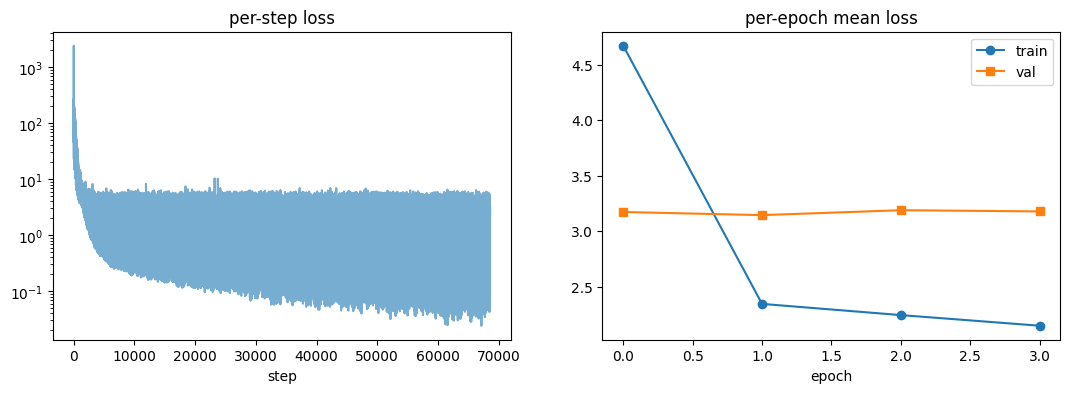

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history["steps"], alpha=0.6)
ax[0].set_yscale("log")
ax[0].set_title("per-step loss")
ax[0].set_xlabel("step")
ax[1].plot(history["train"], "o-", label="train")
ax[1].plot(history["val"], "s-", label="val")
ax[1].set_title("per-epoch mean loss")
ax[1].set_xlabel("epoch")
ax[1].legend()
plt.show()

## 7. Test — distance-AP on the held-out log

Center-distance (AV2-style bands): a detection is a TP if its centre lands within 0.5/1/2/4 m of an unmatched GT centre of the same class. Loads the best-val checkpoint first.

In [9]:
model.load_state_dict(torch.load(CKPT, weights_only=True)["model"])
report = evaluate_model(model, val_frames, input_fn=input_fn, device=DEVICE)
print_ap_report(report)
save_report(report,
            RESULTS)  # results/<MODEL>.json — reload in §9 to compare runs

class         AP@0.5  AP@1    AP@2    AP@4      mean   n_gt
-----------------------------------------------------------
VEHICLE       0.243   0.424   0.495   0.533   0.424  15975
PERSON        0.124   0.159   0.172   0.182   0.159  2911
TWO_WHEELER   0.086   0.132   0.144   0.164   0.131  2090
TRAFFIC_SIGN  0.058   0.060   0.070   0.082   0.067  1503
TRAIN         0.000   0.000   0.000   0.000   0.000  112

F1-optimal operating point @2 m (apply 'confidence >= score' at deployment):
class         prec    recall  F1      score   
----------------------------------------------
VEHICLE       0.582   0.543   0.562   0.198   
PERSON        0.443   0.243   0.314   0.101   
TWO_WHEELER   0.311   0.236   0.268   0.112   
TRAFFIC_SIGN  0.242   0.184   0.209   0.101   
TRAIN         0.000   0.000   0.000   nan     

mAP 0.156 | macro P 0.316 R 0.241 F1 0.271 @2 m | mean centre error (TP@2m) 0.610 m | 3026 frames


PosixPath('results/camera_yolo26_igev.json')

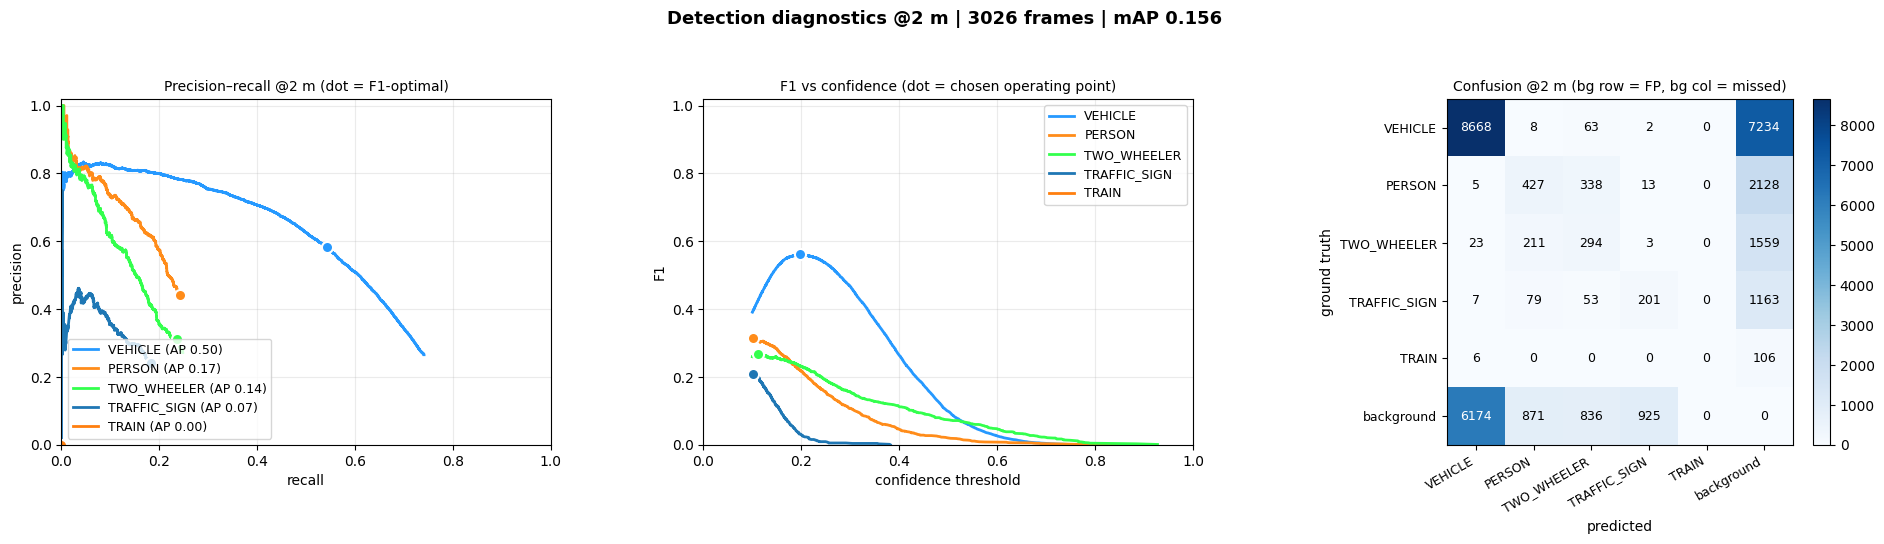

In [21]:
# PR curves + F1-vs-confidence (read the deployment threshold off the peak)
# + confusion matrix (background row = FP, background column = missed GT)

import importlib, utils
importlib.reload(utils)


utils.visualize_evaluation(report)

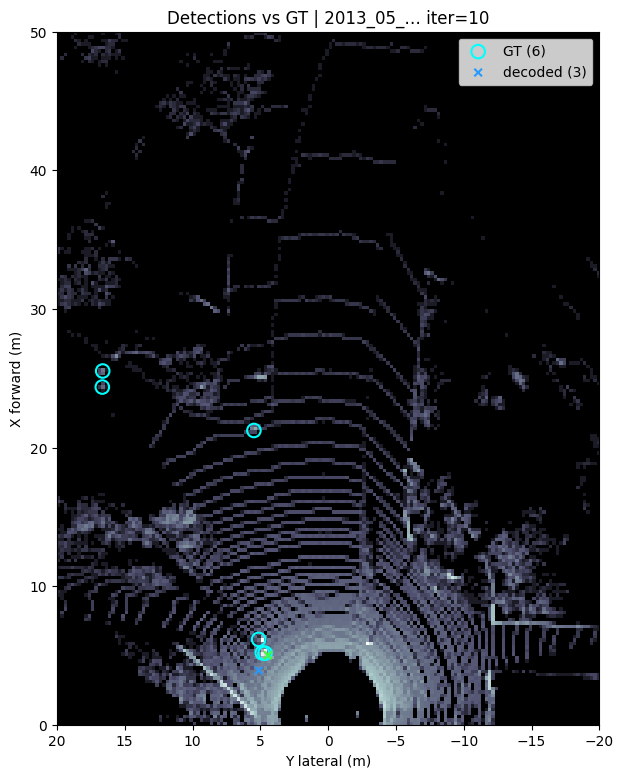

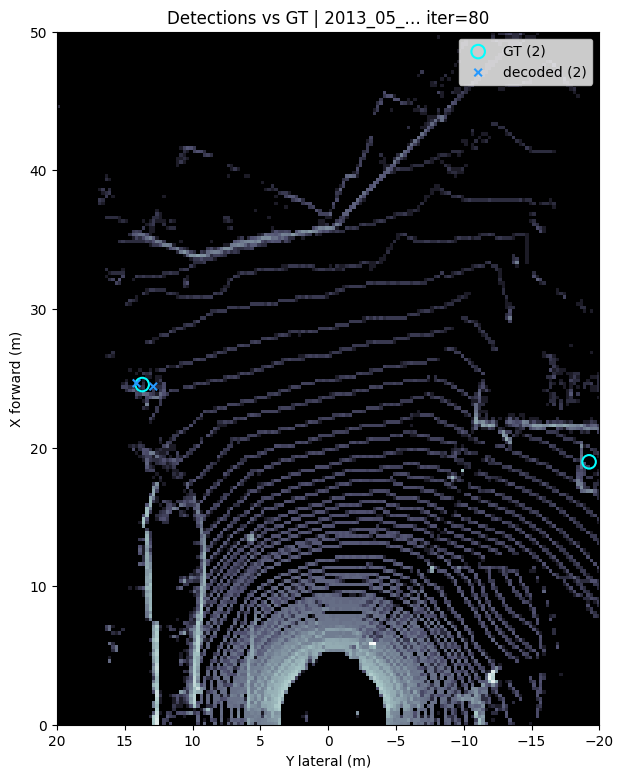

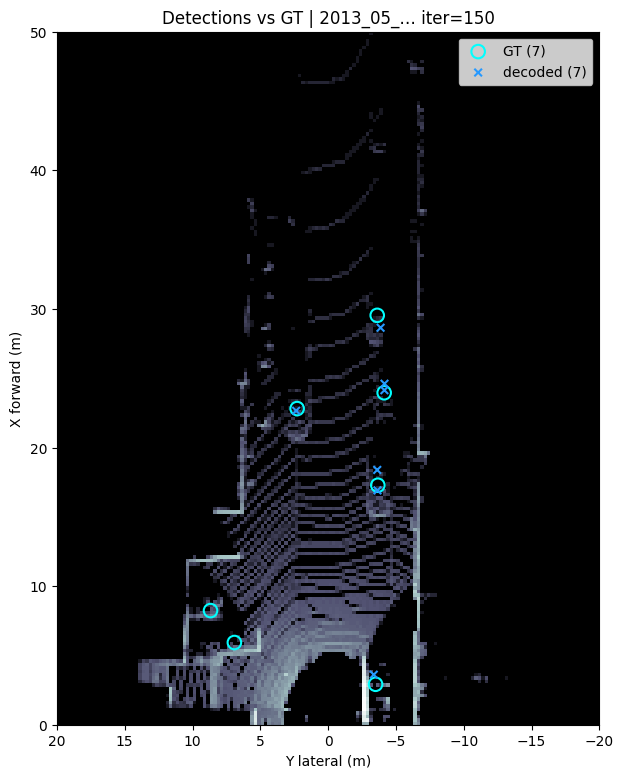

In [22]:
# qualitative check: decoded detections vs GT on a few val frames
model.eval()
decoder = CenterPointDecoder(score_threshold=0.2)
for frame in val_frames[10:151:70]:
    sample = frame.to_stereo_sample()
    with torch.no_grad():
        out = model(input_fn(sample) if input_fn else sample, device=DEVICE)
    det = decoder(out["heatmap"].cpu(), out["offset"].cpu())[0]
    utils.visualize_detections(sample, det)

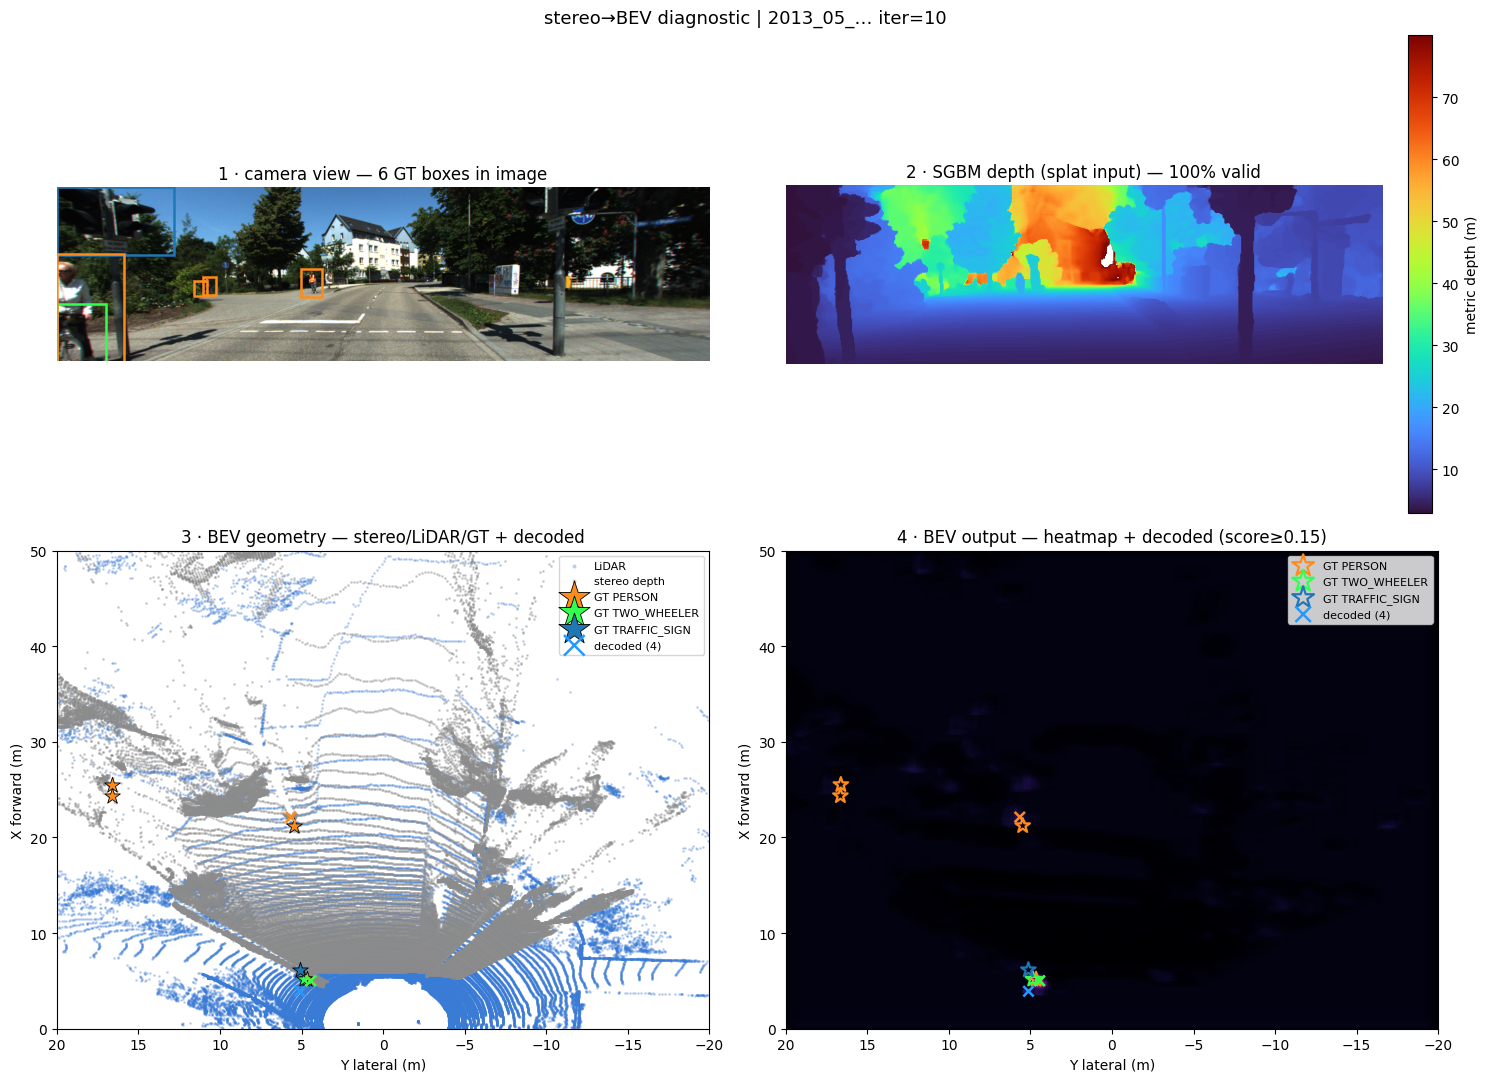

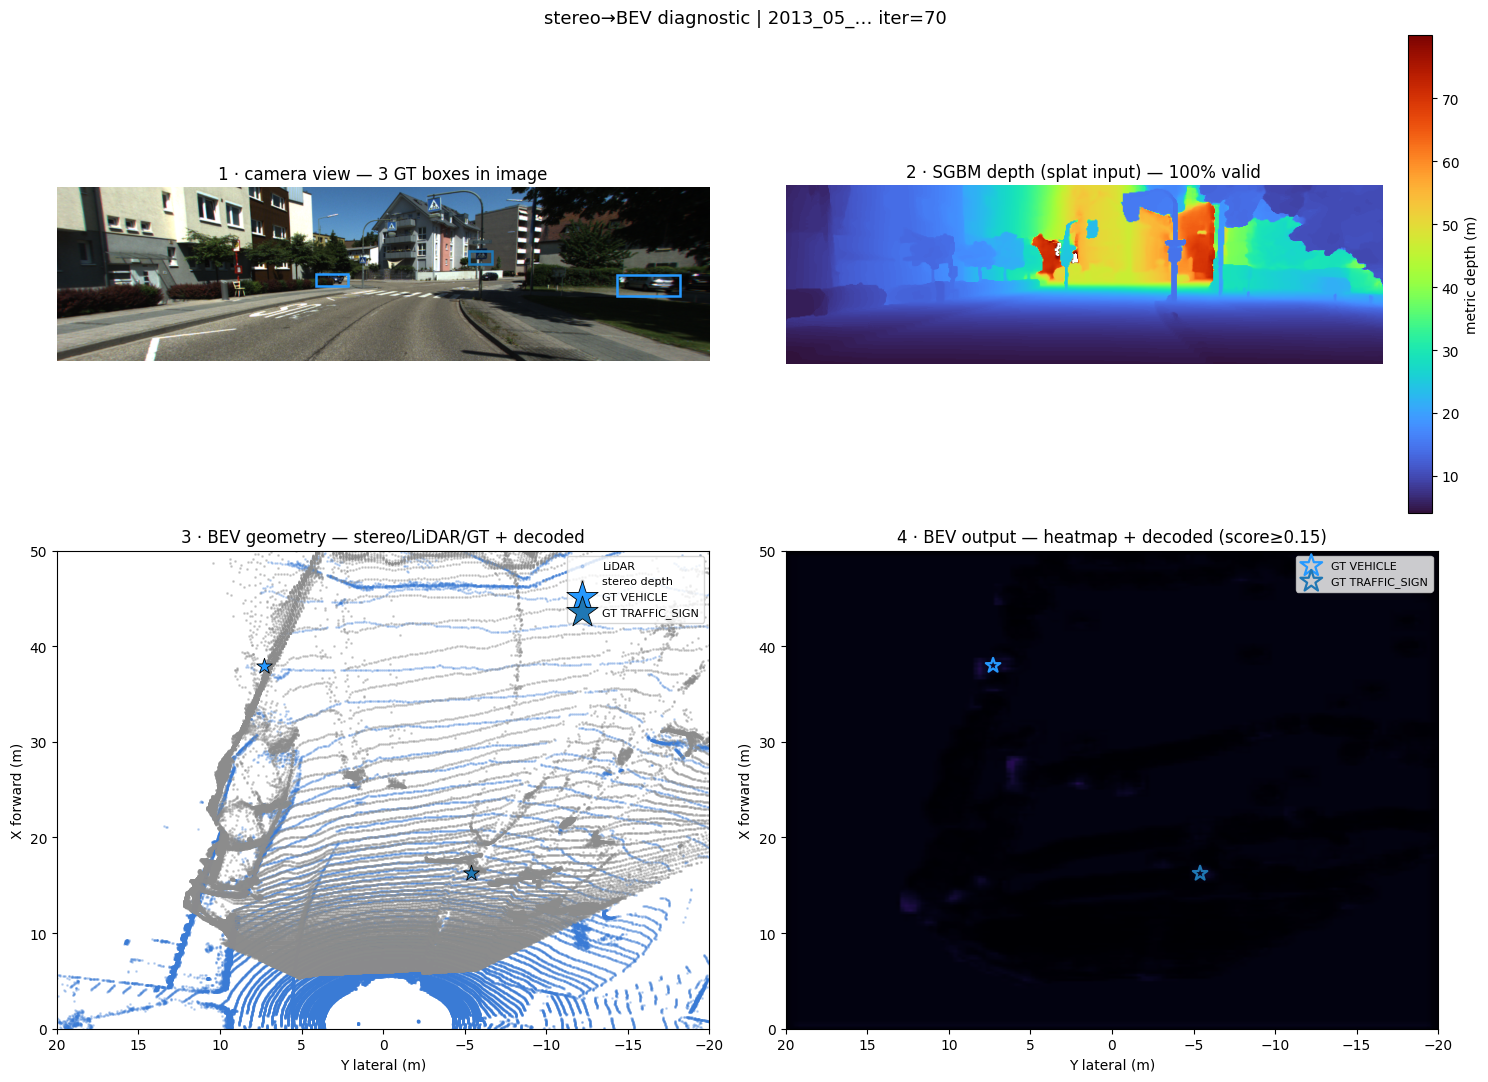

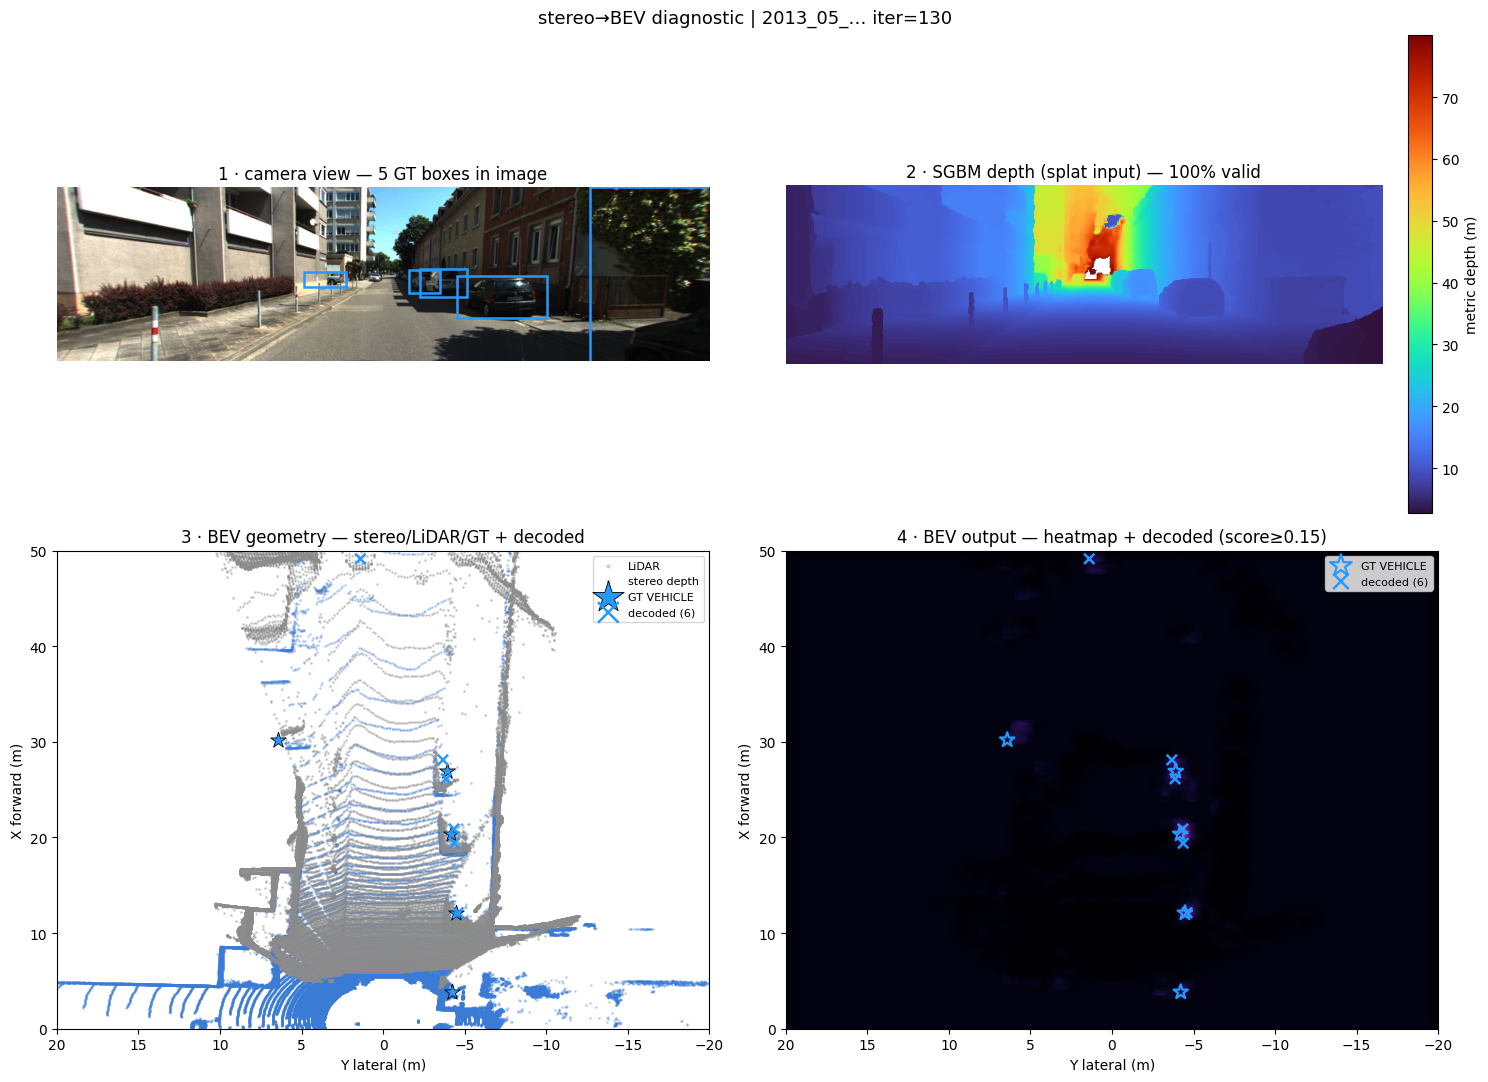

In [23]:
# stereo -> BEV diagnostic: does the net SEE objects (panel 1) but fail to PLACE
# them in BEV because the stereo depth is missing/wrong (panel 3) -> empty output
# (panel 4)? Needs full samples (images). Camera / pipeline_a only.
if MODEL != "lidar":
    for frame in val_frames[10:151:60]:
        sample = frame.to_stereo_sample()  # full sample (load_images=True)
        utils.visualize_stereo_bev_diagnostic(model,
                                              sample,
                                              device=DEVICE,
                                              score_threshold=0.15)
else:
    print("stereo diagnostic is camera/fusion only (needs the stereo branch)")

## 8. Branch contribution (fused runs only)

Two complementary measurements:

1. **Baselines table** — train `lidar`, `camera`, `pipeline_a` with this same notebook (same split/seed/epochs) and compare their AP tables. Fusion's contribution = `pipeline_a` − best single-sensor baseline.
2. **Branch dropout** — evaluate the *trained* fused model with one branch zeroed (`drop_branch`): the AP drop is that branch's marginal contribution inside the fusion. Caveat: a zeroed map is a "silent sensor" the fusion conv never saw in training — it bounds the contribution, it's not a retrained baseline.

In [13]:
if MODEL == "pipeline_a":
    for drop in (None, "camera", "lidar"):
        model.drop_branch = drop
        rep = evaluate_model(model,
                             val_frames,
                             input_fn=input_fn,
                             device=DEVICE)
        print(f"\n=== drop_branch = {drop} "
              f"(mAP {rep['mAP']:.3f}) {'=' * 30}")
        print_ap_report(rep)
    model.drop_branch = None  # always reset
else:
    print(
        "single-sensor run — train MODEL='pipeline_a' for the dropout ablation"
    )

single-sensor run — train MODEL='pipeline_a' for the dropout ablation


## 8b. Pipeline D — late fusion (baseline)

No training: **merge the object lists** of the trained LiDAR-only and camera-only detectors, then score the union with the same distance-AP. Run **after** training `MODEL='lidar'` and `MODEL='camera'` (their checkpoints must exist). Writes `results/pipeline_d.json` so it joins the §9 comparison.

class         AP@0.5  AP@1    AP@2    AP@4      mean   n_gt
-----------------------------------------------------------
VEHICLE       0.410   0.621   0.678   0.696   0.601  15975
PERSON        0.213   0.237   0.245   0.262   0.239  2911
TWO_WHEELER   0.144   0.195   0.207   0.228   0.194  2090
TRAFFIC_SIGN  0.248   0.253   0.264   0.290   0.264  1503
TRAIN         0.000   0.000   0.000   0.000   0.000  112

F1-optimal operating point @2 m (apply 'confidence >= score' at deployment):
class         prec    recall  F1      score   
----------------------------------------------
VEHICLE       0.660   0.671   0.666   0.259   
PERSON        0.338   0.334   0.336   0.151   
TWO_WHEELER   0.387   0.255   0.307   0.183   
TRAFFIC_SIGN  0.467   0.253   0.328   0.218   
TRAIN         0.000   0.000   0.000   nan     

mAP 0.260 | macro P 0.370 R 0.303 F1 0.327 @2 m | mean centre error (TP@2m) 0.483 m | 3026 frames


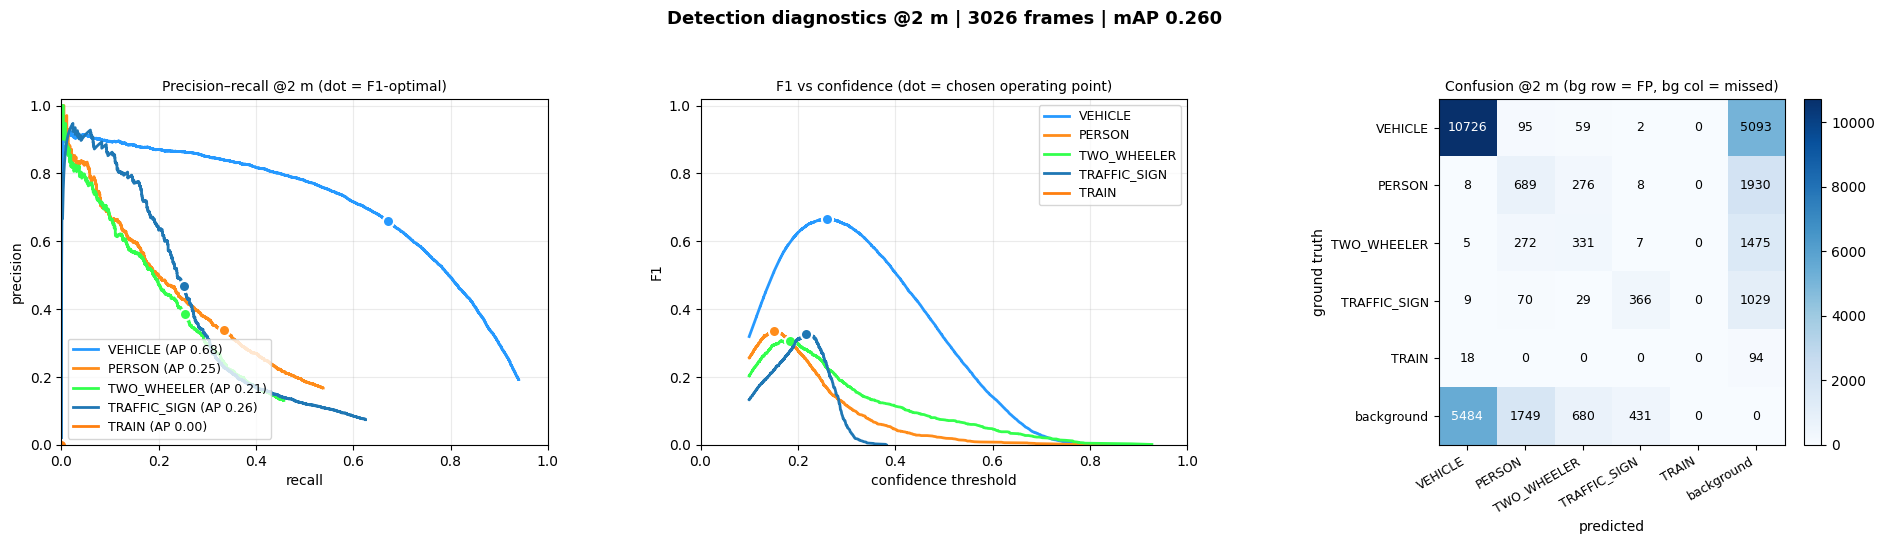

In [14]:
lidar_ckpt = "checkpoints/lidar.pt"
camera_ckpt = f"checkpoints/camera_{CAMERA_BACKBONE}_{MATCHER}.pt"

if Path(lidar_ckpt).exists() and Path(camera_ckpt).exists():
    lm = LidarOnlyDetector()
    lm.load_state_dict(torch.load(lidar_ckpt, weights_only=True)["model"])
    cm = CameraOnlyDetector(
        stereo_cache_root=CACHE_ROOT,
        stereo_cfg=StereoBEVConfig(img_backbone=CAMERA_BACKBONE,
                                   yolo_freeze=FREEZE_BACKBONE))
    cm.load_state_dict(torch.load(camera_ckpt, weights_only=True)["model"])
    report_d = evaluate_late_fusion(lm.to(DEVICE), cm.to(DEVICE), val_frames,
                                    device=DEVICE, merge_radius_m=1.0)
    print_ap_report(report_d)
    save_report(report_d, "results/pipeline_d.json")
    utils.visualize_evaluation(report_d)
else:
    print("Pipeline D needs checkpoints/lidar.pt + camera_*.pt — "
          "train MODEL='lidar' and MODEL='camera' first.")

## 9. Compare saved approaches

Every §7 run wrote `results/<MODEL>.json`. Load them all back and print one
table — no re-evaluation needed. Run this after you've trained + tested each of
`lidar`, `camera`, `pipeline_a` (same split/seed). The per-class columns are the
mean AP over the 0.5/1/2/4 m thresholds; P/R/F1 are macro at the 2 m operating
point. Fusion's contribution = `pipeline_a` row − best single-sensor row.

In [16]:
from pathlib import Path

# skip *_history.json (loss curves, not AP reports) — only load the AP reports
runs = {p.stem: load_report(p)
        for p in sorted(Path("results").glob("*.json"))
        if not p.stem.endswith("_history")}
if runs:
    compare_reports(runs)
else:
    print("no saved reports yet — run §7 for each MODEL first")

model               VEHICLE    PERSON     TWO_WHEELE TRAFFIC_SI TRAIN      mAP    P      R      F1     err(m)
-------------------------------------------------------------------------------------------------------------
camera_yolo26_igev  0.424      0.159      0.131      0.067      0.000      0.156  0.316  0.241  0.271  0.610
lidar               0.543      0.156      0.140      0.269      0.000      0.222  0.314  0.274  0.286  0.468
pipeline_d          0.601      0.239      0.194      0.264      0.000      0.260  0.370  0.303  0.327  0.483


## Next

- **Compare pipelines:** run `MODEL` = `"lidar"` → `"camera"` → `"pipeline_a"` → `"pipeline_b"` → `"pipeline_c"` (same split/seed), then §9 loads every `results/*.json` into one AP table. Fusion's contribution = pipeline row − best single-sensor row.
- **Class caveats (5-class unified):** `TRAIN` (~5 boxes, drive 0010 only → never in train) will sit near 0 AP — expected, it is eval-only. `GENERIC_OBJECT` (poles/box/…) and `trafficLight` are excluded. The well-supported classes are VEHICLE / PERSON / TWO_WHEELER / TRAFFIC_SIGN.
- **More data / balance:** add richer drives via `TRAIN_SEQ="… 0000 0006" scripts/get_kitti360.sh` (sizes in the download table); each is 30–45 GB. Keep drive 0010 as the val drive so results stay comparable.
- BEV augmentation (rotation/flip), warm-start the fused run from the baselines, per-range AP bins, and the full CDS metric.